# Assumption: the data from all the treated reservoirs is available up to the same date

### Import modules and data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import numpy as np
from sklearn.metrics.pairwise import haversine_distances

# Setting up the path to include the parent directory
sys.path.append(str(Path.cwd().parent.parent))
from backend.config.settings import PATHS
from backend.transferring.predicting import predict_one_year, predict_one_year_sarima

critical_threshold = 0.075
worrying_threshold = 0.15
could_give_if_critical = 0.25
could_give_if_worrying = 0.35
able_to_donate = 0.6
cost_threshold = 1.5
epsilon = 1e-10

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
water_path = PATHS['definitive_notebooks'] / 'water_definitive.parquet'
water_pd = pd.read_parquet(water_path)
water_pd.head()

,date,storage,id,storage_imputed
0,1988-01-05,0,3,0
1,1988-01-12,0,3,0
2,1988-01-19,0,3,0
3,1988-01-26,0,3,0
4,1988-02-02,0,3,0


In [3]:
reservoirs_path = PATHS['definitive_notebooks'] / 'reservoirs_merged.parquet'
reservoirs_pd = pd.read_parquet(reservoirs_path)
reservoirs_pd.head()

,id,scope,name,capacity,electric_flag,longitude,latitude,basin,riverbed,google,openstreetmap,wikidata,province,autonomous_community,type,crest_elevation,dam_height,report
0,3,guadalquivir,fernandina,247.0,0,38.179646,-3.570224,guadalquivir,rio guarrizas,None,None,None,jaen,andalucia,presa fabrica gravedad (hormigon vibrado),719.55,NaN,https://sig.mapama.gob.es/WebServices/clientew...
1,5,guadalquivir,puebla cazalla,87.0,0,37.129772,-5.243309,guadalquivir,rio corbones,None,None,None,sevilla,andalucia,presa fabrica gravedad (hormigon compactado),218.25,NaN,https://sig.mapama.gob.es/WebServices/clientew...
2,9,cuenca mediterranea andaluza,vinuela,170.0,0,36.860400,-4.164435,cuencas mediterraneas andaluzas,rio guaro,https://www.google.com/search?kgmid=/g/120jr2sh,None,https://www.wikidata.org/wiki/Q5830515,malaga,andalucia,presa materiales sueltos pantalla hormigon,426.00,NaN,https://sig.mapama.gob.es/WebServices/clientew...
3,11,cuenca mediterranea andaluza,rules,111.0,0,36.860510,-3.495430,cuencas mediterraneas andaluzas,rio guadalfeo o rio cadiar,https://www.google.com/search?kgmid=/g/121vx8sj,None,https://www.wikidata.org/wiki/Q5369455,granada,andalucia,presa fabrica arco gravedad,426.00,NaN,https://sig.mapama.gob.es/WebServices/clientew...
4,12,guadiana,burdalo,79.0,0,-1.112043,42.606125,jucar,riu amadorio,None,None,None,caceres,extremadura,None,320.65,NaN,None


In [4]:
def calculate_cost_matrix(reservoirs_definitive):
    reservoirs = sorted(reservoirs_definitive.index)
    coords_rad = np.radians(reservoirs_definitive[['latitude','longitude']].to_numpy())
    distance_matrix = haversine_distances(coords_rad, coords_rad) * 6371.0  # shape (N,N) in km
    # cost_matrix[i,j] means the cost of reservoir i to transfer water to reservoir j
    value_matrix = distance_matrix.copy()
    value_matrix = value_matrix / value_matrix.max()  # Normalize distances by the maximum distance in each row
    value_matrix = 4*value_matrix
    value_matrix = 1 / (value_matrix + epsilon)

    median_capacity = np.median(reservoirs_definitive['capacity'].values)

    for i in range(len(reservoirs)):
        # The next operation only depends on the donor reservoir's characteristics, not the receiver
        value_matrix[i, :] = value_matrix[i, :] * (reservoirs_definitive.loc[reservoirs[i], 'capacity'] / median_capacity) * (reservoirs_definitive.loc[reservoirs[i], 'ability_to_transfer_rate'] + epsilon * 1e4)
        # The next operation only depends on the receiver reservoir's characteristics, not the donor
        value_matrix[:, i] = value_matrix[:, i] / (reservoirs_definitive.loc[reservoirs[i], 'capacity'] / median_capacity * (reservoirs_definitive.loc[reservoirs[i], 'urgent_need_to_receive_rate'] + epsilon * 1e4))

    cost_matrix = 1 / value_matrix


    for i  in range(len(reservoirs)):
        cost_matrix[i,i] = np.inf
        if not (reservoirs_definitive.loc[reservoirs[i], 'could_give_if_critical']):
            cost_matrix[i,:] = np.full(len(reservoirs), np.inf)

    return cost_matrix, distance_matrix

In [5]:
def initial_state(reservoirs_list, plotting=False, critical_threshold=critical_threshold, worrying_threshold=worrying_threshold, could_give_if_critical=could_give_if_critical, could_give_if_worrying=could_give_if_worrying, able_to_donate=able_to_donate):
    water_restricted = water_pd[water_pd['id'].isin(reservoirs_list)]
    reservoirs_restricted = reservoirs_pd[reservoirs_pd['id'].isin(reservoirs_list)]

    reservoirs_list = sorted(reservoirs_restricted['id'].unique())
    first_reservoir_data = water_restricted[water_restricted['id']==reservoirs_list[0]].sort_values(by='date')
    first_week_considered = first_reservoir_data.iloc[-52]['date']
    series_index = pd.date_range(start=first_week_considered, periods=52*2, freq='7D')

    water_definitive = pd.DataFrame()
    for reservoir in reservoirs_restricted['id']:
        water_one_reservoir = pd.DataFrame()
        water_one_reservoir.loc[:, 'date'] = series_index
        water_one_reservoir.loc[water_one_reservoir['date'] < water_one_reservoir['date'][52], 'storage'] = water_restricted[water_restricted['id'] == reservoir].sort_values(by='date')['storage'][-52:].values
        try:
            water_one_reservoir.loc[water_one_reservoir['date'] >= water_one_reservoir['date'][52], 'storage'] = predict_one_year(reservoir, 4, plotting=plotting).values
        except Exception as e:
            water_one_reservoir.loc[water_one_reservoir['date'] >= water_one_reservoir['date'][52], 'storage'] = predict_one_year_sarima(reservoir).values
        water_one_reservoir.loc[:, 'id'] = reservoir
        water_definitive = pd.concat([water_definitive, water_one_reservoir], axis=0, ignore_index=True)

    water_definitive.sort_values(by=['id', 'date'], inplace=True)

    reservoirs_definitive = reservoirs_restricted[['id', 'name', 'capacity', 'latitude', 'longitude', 'crest_elevation']].copy()
    reservoirs_definitive.set_index('id', inplace=True)
    for reservoir in reservoirs_list:
        reservoirs_definitive.loc[reservoir, 'last_known_value'] = water_definitive[water_definitive['id'] == reservoir].sort_values(by='date')['storage'].values[-53]
        reservoirs_definitive.loc[reservoir, 'low_forecasted_value'] = water_definitive[water_definitive['id'] == reservoir][-52:].sort_values(by='storage')['storage'].values[5]
        reservoirs_definitive.loc[reservoir, 'high_forecasted_value'] = water_definitive[water_definitive['id'] == reservoir][-52:].sort_values(by='storage')['storage'].values[-5]
        reservoirs_definitive.loc[reservoir, 'median_forecasted_value'] = water_definitive[water_definitive['id'] == reservoir][-52:].sort_values(by='storage')['storage'].values[26]

    reservoirs_definitive.loc[:, 'urgent_need_to_receive_rate'] = reservoirs_definitive['low_forecasted_value'] / reservoirs_definitive['capacity']
    reservoirs_definitive.loc[:, 'ability_to_transfer_rate'] = reservoirs_definitive['median_forecasted_value']  / reservoirs_definitive['capacity']
    reservoirs_definitive.loc[:, 'critical'] = (reservoirs_definitive['urgent_need_to_receive_rate'] < critical_threshold).astype(int)
    reservoirs_definitive.loc[:, 'worrying'] = (reservoirs_definitive['urgent_need_to_receive_rate'] < worrying_threshold).astype(int)
    reservoirs_definitive.loc[:, 'could_give_if_critical'] = (reservoirs_definitive['ability_to_transfer_rate'] > could_give_if_critical).astype(int)
    reservoirs_definitive.loc[:, 'could_give_if_worrying'] = (reservoirs_definitive['ability_to_transfer_rate'] > could_give_if_worrying).astype(int)
    reservoirs_definitive.loc[:, 'able_to_donate'] = (reservoirs_definitive['ability_to_transfer_rate'] > able_to_donate).astype(int)

    cost_matrix, distance_matrix = calculate_cost_matrix(reservoirs_definitive)

    return reservoirs_definitive, cost_matrix, distance_matrix

In [6]:
reservoirs = sorted(reservoirs_pd[reservoirs_pd['province'] == 'cadiz']['id'].values)
reservoirs_cadiz, cost_matrix_cadiz, distance_matrix_cadiz = initial_state(reservoirs, plotting=False)
reservoirs_cadiz

,name,capacity,latitude,longitude,crest_elevation,last_known_value,low_forecasted_value,high_forecasted_value,median_forecasted_value,urgent_need_to_receive_rate,ability_to_transfer_rate,critical,worrying,could_give_if_critical,could_give_if_worrying,able_to_donate
id,,,,,,,,,,,,,,,,
113,barbate,228.0,-5.741442,36.370443,107.2,27.0,24.904858,41.198003,31.898070,0.109232,0.139904,0,1,0,0,0
212,zahara,223.0,-5.389723,36.855622,108.5,25.0,12.388605,29.226905,23.496364,0.055554,0.105365,1,1,0,0,0
240,almodovar,6.0,-5.649731,36.153615,107.2,3.0,2.628943,4.584908,3.559181,0.438157,0.593197,0,0,1,1,0
242,guadarranque,88.0,-5.461460,36.308767,107.2,30.0,25.558384,40.278598,33.328290,0.290436,0.378731,0,0,1,1,0
326,charco redondo,82.0,-5.544162,36.232200,107.2,18.0,15.882052,21.917653,18.000000,0.193684,0.219512,0,0,0,0,0
328,guadalcacin ii,800.0,-5.786804,36.668051,110.0,139.0,112.942795,142.440832,129.020704,0.141178,0.161276,0,1,0,0,0
375,hurones,135.0,-5.561925,36.661371,110.0,90.0,82.432682,110.949536,99.856216,0.610612,0.739676,0,0,1,1,1
571,celemin,45.0,-5.774432,36.299322,107.2,6.0,5.479270,12.784855,7.620948,0.121762,0.169354,0,1,0,0,0
623,arcos,14.0,-5.795583,36.751339,108.5,13.0,12.763966,13.218763,12.976702,0.911712,0.926907,0,0,1,1,1


In [7]:
def update_cost_matrix(donor, receiver, cost_matrix, distance_matrix, reservoirs_updated):
    """
    Vectorized update of donor row and receiver column using the same logic as calculate_cost_matrix.
    """
    reservoirs = sorted(reservoirs_updated.index)
    id_to_index = {id: i for i, id in enumerate(reservoirs)}
    
    def update_cost_matrix_one_reservoir(reservoir_idx, reservoir_id):
        median_capacity = np.median(reservoirs_updated['capacity'].values)
        
        # Step 1: Start with normalized distance base
        normalized_distances_row = distance_matrix[reservoir_idx, :] / distance_matrix.max()
        normalized_distances_col = distance_matrix[:, reservoir_idx] / distance_matrix.max()
        
        # Convert to base values
        base_values_row = 1 / (4 * normalized_distances_row + epsilon)
        base_values_col = 1 / (4 * normalized_distances_col + epsilon)

        # Apply donor characteristics
        donor_factor = (reservoirs_updated.loc[reservoir_id, 'capacity'] / median_capacity) * (reservoirs_updated.loc[reservoir_id, 'ability_to_transfer_rate'] + 1e4 * epsilon)
        
        # Get receiver characteristics for all reservoirs
        receiver_factors_row = np.array([
            (reservoirs_updated.loc[rid, 'capacity'] / median_capacity) * 
            reservoirs_updated.loc[rid, 'urgent_need_to_receive_rate']
            for rid in reservoirs
        ])
        
        # Calculate row values and convert to costs
        value_row = base_values_row * donor_factor / receiver_factors_row
        cost_matrix[reservoir_idx, :] = 1 / value_row
        
        # Apply receiver characteristics
        receiver_factor = (reservoirs_updated.loc[reservoir_id, 'capacity'] / median_capacity) * (reservoirs_updated.loc[reservoir_id, 'urgent_need_to_receive_rate'] + 1e4 * epsilon)

        # Get donor characteristics for all reservoirs
        donor_factors_col = np.array([
            (reservoirs_updated.loc[rid, 'capacity'] / median_capacity) * 
            reservoirs_updated.loc[rid, 'ability_to_transfer_rate']
            for rid in reservoirs
        ])
        
        # Calculate column values and convert to costs
        value_col = base_values_col * donor_factors_col / receiver_factor
        cost_matrix[:, reservoir_idx] = 1 / value_col
        
        cost_matrix[reservoir_idx, reservoir_idx] = np.inf  # No self-transfer
        
        # Block entire row if reservoir cannot give
        if not reservoirs_updated.loc[reservoir_id, 'could_give_if_critical']:
            cost_matrix[reservoir_idx, :] = np.inf
    
    update_cost_matrix_one_reservoir(id_to_index[donor], donor)
    update_cost_matrix_one_reservoir(id_to_index[receiver], receiver)
    
    return cost_matrix

In [8]:
def calculate_difference(reservoirs, donor, receiver):
    capacity_donor = reservoirs.loc[donor, 'capacity']
    capacity_receiver = reservoirs.loc[receiver, 'capacity']
    current_storage_donor = reservoirs.loc[donor, 'last_known_value']
    current_storage_receiver = reservoirs.loc[receiver, 'last_known_value']
    ponderation_donor = capacity_donor / (capacity_donor + capacity_receiver)
    difference = current_storage_donor - ponderation_donor * (current_storage_donor + current_storage_receiver)
    return difference

In [9]:
def update_reservoirs_equal_percentage(reservoirs_definitive, donor, receiver):
    '''
    Updates the reservoirs by transferring water from the donor to the receiver
    in a way that maintains the same percentage of water in both reservoirs.

    Doesn't change the given reservoir.
    '''
    reservoirs = reservoirs_definitive.copy()
    difference = calculate_difference(reservoirs, donor, receiver)

    def update_one_reservoir(reservoir, difference):
        reservoirs.loc[reservoir, ['last_known_value', 'low_forecasted_value', 'high_forecasted_value', 'median_forecasted_value']] += difference
        reservoirs.loc[reservoir, 'urgent_need_to_receive_rate'] = reservoirs.loc[reservoir, 'low_forecasted_value'] / reservoirs.loc[reservoir, 'capacity']
        reservoirs.loc[reservoir, 'ability_to_transfer_rate'] = reservoirs.loc[reservoir, 'median_forecasted_value'] / reservoirs.loc[reservoir, 'capacity']
        reservoirs.loc[reservoir, 'critical'] = (reservoirs.loc[reservoir, 'urgent_need_to_receive_rate'] < critical_threshold).astype(int)
        reservoirs.loc[reservoir, 'worrying'] = (reservoirs.loc[reservoir, 'urgent_need_to_receive_rate'] < worrying_threshold).astype(int)
        reservoirs.loc[reservoir, 'could_give_if_critical'] = (reservoirs.loc[reservoir, 'ability_to_transfer_rate'] > could_give_if_critical).astype(int)
        reservoirs.loc[reservoir, 'could_give_if_worrying'] = (reservoirs.loc[reservoir, 'ability_to_transfer_rate'] > could_give_if_worrying).astype(int)
        reservoirs.loc[reservoir, 'able_to_donate'] = (reservoirs.loc[reservoir, 'ability_to_transfer_rate'] > able_to_donate).astype(int)

    update_one_reservoir(donor, -difference)
    update_one_reservoir(receiver, difference)

    return reservoirs, difference


In [10]:
def perform_best_transfer(reservoirs_definitive, cost_matrix, cost_threshold, accept_worrying=True):
    '''
    Performs the best transfer that fixes a critical, and if not possible, a worrying reservoir, following the costs.

    Aspects
    --------
    - It gives priority to critical receivers over worrying ones.
    - By default, a critical transfer whose involved reservoirs may end up as worrying (but neither of them critical), is accepted. If this is not desired, set accept_worrying to False.

    Returns
    -------
    - A DataFrame with the updated reservoirs if a valid transfer is found, otherwise the original DataFrame.
    - A boolean that is True if the given reservoir has been modified.
    '''
    def perform_best_transfer_for_given_columns(columns, state_receiver):
        i = 0
        index_to_id = {i: id for i, id in enumerate(reservoirs_definitive.index)}
        sorted_costs = np.sort(cost_matrix[:, columns], axis=None)
        while i < len(sorted_costs) and sorted_costs[i] < cost_threshold:
            # Get the indices of the reservoirs involved in this transfer
            reservoir_pair = np.where(cost_matrix[:, columns] == sorted_costs[i])
            donor = reservoir_pair[0][0]
            receiver = reservoir_pair[1][0]
            donor = index_to_id[donor]
            receiver = index_to_id[columns[receiver]]
            if reservoirs_definitive.loc[donor, f'could_give_if_{state_receiver}']:

                temptative_reservoirs_definitive, difference = update_reservoirs_equal_percentage(reservoirs_definitive, donor, receiver)
                transfer = {'donor': donor, 'receiver': receiver, 'difference': difference, 'cost': sorted_costs[i],
                                           'critical': temptative_reservoirs_definitive.loc[receiver, 'critical'],
                                           'worrying': temptative_reservoirs_definitive.loc[receiver, 'worrying'],
                                           'could_give_if_critical': temptative_reservoirs_definitive.loc[donor, 'could_give_if_critical'],
                                           'could_give_if_worrying': temptative_reservoirs_definitive.loc[donor, 'could_give_if_worrying'],
                                           'able_to_donate': temptative_reservoirs_definitive.loc[donor, 'able_to_donate']}

                if state_receiver == 'critical':
                    if (not temptative_reservoirs_definitive.loc[receiver, 'worrying']) and (not temptative_reservoirs_definitive.loc[donor, 'worrying']):
                        return temptative_reservoirs_definitive, True, transfer
                    elif accept_worrying and (not temptative_reservoirs_definitive.loc[receiver, 'critical']) and (not temptative_reservoirs_definitive.loc[donor, 'critical']):
                        return temptative_reservoirs_definitive, True, transfer
                    else:
                        i += 1
                        continue
                
                if state_receiver == 'worrying':
                    if (not temptative_reservoirs_definitive.loc[receiver, 'worrying']) and (not temptative_reservoirs_definitive.loc[donor, 'worrying']):
                        return temptative_reservoirs_definitive, True, transfer
                    else:
                        i += 1

            else:
                i += 1
        return pd.DataFrame(), False, None

    id_to_index = {id: i for i, id in enumerate(reservoirs_definitive.index)}
    critical_indices = np.sort(reservoirs_definitive[reservoirs_definitive['critical']==1].index.map(id_to_index).values)
    temptative_reservoirs_definitive, bool, transfer = perform_best_transfer_for_given_columns(critical_indices, 'critical')
    if bool:
        return temptative_reservoirs_definitive, True, transfer
    else:
        worrying_indices = np.sort(reservoirs_definitive[reservoirs_definitive['worrying']==1].index.map(id_to_index).values)
        worrying_indices = [i for i in worrying_indices if i not in critical_indices]
        temptative_reservoirs_definitive, bool, transfer = perform_best_transfer_for_given_columns(worrying_indices, 'worrying')
        if bool:
            return temptative_reservoirs_definitive, True, transfer
        else:
            return reservoirs_definitive, False, transfer


In [11]:
def show_best_transfers(reservoirs, cost_matrix):
    '''
    Shows the best possible transfers but segmented into three groups:
        - Critical receiver
        - Worrying receiver
        - Rest of the receivers
    Each of them ordered by cost
    '''
    def show_best_transfers_for_given_columns(columns):
        i = 0
        index_to_id = {i: id for i, id in enumerate(reservoirs.index)}
        sorted_costs = np.sort(cost_matrix[:, columns], axis=None)
        transfers = pd.DataFrame(columns=['donor', 'receiver', 'difference', 'cost', 'critical', 'worrying', 'could_give_if_critical', 'could_give_if_worrying', 'able_to_donate'])
        while i < len(sorted_costs) and sorted_costs[i] < cost_threshold:
            # Get the indices of the reservoirs involved in this transfer
            reservoir_pair = np.where(cost_matrix[:, columns] == sorted_costs[i])
            donor = reservoir_pair[0][0]
            receiver = reservoir_pair[1][0]
            donor = index_to_id[donor]
            receiver = index_to_id[columns[receiver]]

            difference = calculate_difference(reservoirs, donor, receiver)

            transfers.loc[len(transfers)] = {'donor': donor, 'receiver': receiver, 'difference': difference, 'cost': sorted_costs[i],
                                           'critical': reservoirs.loc[receiver, 'critical'],
                                           'worrying': reservoirs.loc[receiver, 'worrying'],
                                           'could_give_if_critical': reservoirs.loc[donor, 'could_give_if_critical'],
                                           'could_give_if_worrying': reservoirs.loc[donor, 'could_give_if_worrying'],
                                           'able_to_donate': reservoirs.loc[donor, 'able_to_donate']}
            i += 1

        return transfers
    

    id_to_index = {id: i for i, id in enumerate(reservoirs.index)}
    critical_indices = reservoirs[reservoirs['critical']==1].index.map(id_to_index).values
    critical_transfers = show_best_transfers_for_given_columns(critical_indices)
    worrying_indices = reservoirs[reservoirs['worrying']==1].index.map(id_to_index).values
    worrying_indices = [i for i in worrying_indices if i not in critical_indices]
    worrying_transfers = show_best_transfers_for_given_columns(worrying_indices)
    rest_of_indices = [i for i in id_to_index.values() if i not in critical_indices and i not in worrying_indices]
    rest_of_transfers = show_best_transfers_for_given_columns(rest_of_indices)
    dfs_to_concat = [df for df in [critical_transfers, worrying_transfers, rest_of_transfers] if not df.empty]
    if dfs_to_concat:
        return pd.concat(dfs_to_concat, axis=0, ignore_index=True)
    else:
        return pd.DataFrame(columns=['donor', 'receiver', 'difference', 'cost', 'critical', 'worrying', 'could_give_if_critical', 'could_give_if_worrying', 'able_to_donate'])

In [12]:
def show_best_transfers_region(latitude, longitude, radius_km, cost_threshold=1.5, accept_worrying=True):
    '''
    Shows the best possible transfers between reservoirs located in a certain radius of action
    '''
    coord_rads = np.radians([latitude, longitude]).reshape(1, -1)
    reservoir_coords_rad = np.radians(reservoirs_pd[['latitude','longitude']].to_numpy())
    
    distances = haversine_distances(coord_rads, reservoir_coords_rad) * 6371.0  # shape (1,N) in km
    mask = distances[0] <= radius_km
    reservoirs = reservoirs_pd.loc[mask, 'id'].unique()
    reservoirs_pd.drop(columns='distance', inplace=True)

    reservoirs_definitive, cost_matrix, _ = initial_state(reservoirs)

    return show_best_transfers(reservoirs_definitive, cost_matrix, cost_threshold=cost_threshold, accept_worrying=accept_worrying)

In [13]:
show_best_transfers(reservoirs_cadiz, cost_matrix_cadiz)

,donor,receiver,difference,cost,critical,worrying,could_give_if_critical,could_give_if_worrying,able_to_donate
0,375,212,46.634078,0.172350,1,1,1,1,1
1,624,212,12.079625,0.432857,1,1,1,0,0
2,242,212,14.437299,1.095102,1,1,1,1,0
3,375,571,18.000000,0.123140,0,1,1,1,1
4,624,571,3.397590,0.248167,0,1,1,0,0
5,242,571,6.180451,0.276180,0,1,1,1,0
6,375,113,46.487603,0.455829,0,1,1,1,1
7,624,113,11.527778,0.965456,0,1,1,0,0
8,623,571,8.491525,1.019899,0,1,1,1,1
9,242,113,14.126582,1.149148,0,1,1,1,0


In [14]:
def update_cost_matrix(donor, receiver, cost_matrix, distance_matrix, reservoirs_updated):
    """
    Vectorized update of donor row and receiver column using the same logic as calculate_cost_matrix.
    """
    reservoirs = sorted(reservoirs_updated.index)
    id_to_index = {id: i for i, id in enumerate(reservoirs)}
    
    def update_cost_matrix_one_reservoir(reservoir_idx, reservoir_id):
        median_capacity = reservoirs_updated['capacity'].values[len(reservoirs) // 2]
        
        # Step 1: Start with normalized distance base (vectorized for entire row/column)
        normalized_distances_row = distance_matrix[reservoir_idx, :] / distance_matrix.max()
        normalized_distances_col = distance_matrix[:, reservoir_idx] / distance_matrix.max()
        
        # Step 2: Convert to base values (following calculate_cost_matrix logic)
        base_values_row = 1 / (4 * normalized_distances_row + 1e-10)
        base_values_col = 1 / (4 * normalized_distances_col + 1e-10)

        # Step 3: Apply donor characteristics to ROW (reservoir donating to all others)
        donor_factor = (reservoirs_updated.loc[reservoir_id, 'capacity'] / median_capacity) * \
                      reservoirs_updated.loc[reservoir_id, 'ability_to_transfer_rate']
        
        # Get receiver characteristics for all reservoirs (vectorized)
        receiver_factors_row = np.array([
            (reservoirs_updated.loc[rid, 'capacity'] / median_capacity) * 
            reservoirs_updated.loc[rid, 'urgent_need_to_receive_rate']
            for rid in reservoirs
        ])
        
        # Calculate row values and convert to costs
        value_row = base_values_row * donor_factor / receiver_factors_row
        cost_matrix[reservoir_idx, :] = 1 / value_row
        
        # Step 4: Apply receiver characteristics to COLUMN (all others donating to reservoir)
        receiver_factor = (reservoirs_updated.loc[reservoir_id, 'capacity'] / median_capacity) * \
                         reservoirs_updated.loc[reservoir_id, 'urgent_need_to_receive_rate']
        
        # Get donor characteristics for all reservoirs (vectorized)
        donor_factors_col = np.array([
            (reservoirs_updated.loc[rid, 'capacity'] / median_capacity) * 
            reservoirs_updated.loc[rid, 'ability_to_transfer_rate']
            for rid in reservoirs
        ])
        
        # Calculate column values and convert to costs
        value_col = base_values_col * donor_factors_col / receiver_factor
        cost_matrix[:, reservoir_idx] = 1 / value_col
        
        # Step 5: Apply constraints (vectorized)
        cost_matrix[reservoir_idx, reservoir_idx] = np.inf  # No self-transfer
        
        # Block entire row if reservoir cannot give
        if not reservoirs_updated.loc[reservoir_id, 'could_give_if_critical']:
            cost_matrix[reservoir_idx, :] = np.inf
    
    # Update both affected reservoirs
    update_cost_matrix_one_reservoir(id_to_index[donor], donor)
    update_cost_matrix_one_reservoir(id_to_index[receiver], receiver)
    
    return cost_matrix

In [15]:
# Calculate the cost matrix after the update
reservoirs = sorted(reservoirs_pd[reservoirs_pd['province'] == 'cadiz']['id'].values)
reservoirs_cadiz, cost_matrix_cadiz, distance_matrix_cadiz = initial_state(reservoirs)
updated_reservoirs_cadiz, difference = update_reservoirs_equal_percentage(reservoirs_cadiz, 375, 212)
calculated_cost_matrix, hola = calculate_cost_matrix(updated_reservoirs_cadiz)


# Update cost matrix from the previous one
coords_rad = np.radians(reservoirs_cadiz[['latitude','longitude']].to_numpy())
updated_cost_matrix = update_cost_matrix(375, 212, cost_matrix_cadiz, distance_matrix_cadiz, updated_reservoirs_cadiz)


calculated_cost_matrix - updated_cost_matrix

C:\Users\usuario\AppData\Local\Temp\ipykernel_26412\910393523.py:13: RuntimeWarning: invalid value encountered in subtract
  calculated_cost_matrix - updated_cost_matrix


array([[            nan,             inf,             nan,
                    nan,             nan,             nan,
                    inf,             nan,             nan,
                    nan],
       [ 6.80084778e-06,             nan, -1.34576445e-07,
         2.82701865e-07,  1.54102256e-06,  1.47984846e-05,
         4.19303643e-07,  1.42234601e-06, -8.52051679e-07,
         1.80397273e-06],
       [ 0.00000000e+00,  1.38796506e-04,             nan,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         5.77161440e-05,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  5.93625896e-06,  0.00000000e+00,
                    nan,  0.00000000e+00,  0.00000000e+00,
         2.37876944e-06,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [            nan,             inf,             nan,
                    nan,             nan,             nan,
                    inf,             nan,             nan,
           

In [16]:
def make_optimal_transfers(reservoirs, cost_threshold=1.5, max_iterations=10, accept_worrying=True, plotting=False):
    '''
    Orchestrates the process of making optimal transfers between reservoirs.
    '''
    # Creates the initial state
    reservoirs_definitive, cost_matrix, distance_matrix = initial_state(reservoirs, plotting)

    iteration = 0
    transfer_done = True
    transfers_log = pd.DataFrame(columns=['donor', 'receiver', 'difference', 'cost', 'critical', 'worrying', 'could_give_if_critical', 'could_give_if_worrying', 'able_to_donate'])

    best_transfers_list = []

    while transfer_done and iteration < max_iterations:
        # Show the best transfers
        best_transfers = show_best_transfers(reservoirs_definitive, cost_matrix)

        if best_transfers.empty:
            break
        else:
            best_transfers_list.append(best_transfers)

        # Perform the best transfer
        reservoirs_definitive, transfer_done, transfer = perform_best_transfer(reservoirs_definitive, cost_matrix, cost_threshold, accept_worrying)
        if transfer_done:
            # Log the transfer
            transfers_log.loc[len(transfers_log)] = transfer
            # Update the cost matrix
            cost_matrix = update_cost_matrix(transfer['donor'], transfer['receiver'], cost_matrix, distance_matrix, reservoirs_definitive)

        iteration += 1

    return reservoirs_definitive, transfers_log

In [17]:
def make_optimal_transfers_region(latitude, longitude, radius_km, cost_threshold=1.5, max_iterations=10, accept_worrying=True):
    '''
    Orchestrates the process of making optimal transfers between reservoirs located in a certain radius of action
    '''
    coord_rads = np.radians([latitude, longitude]).reshape(1, -1)
    reservoir_coords_rad = np.radians(reservoirs_pd[['latitude','longitude']].to_numpy())
    
    reservoirs_pd['distance'] = (haversine_distances(coord_rads, reservoir_coords_rad) * 6371.0).reshape(-1)
    mask = reservoirs_pd['distance'] <= radius_km
    reservoirs = reservoirs_pd.loc[mask, 'id'].unique()
    reservoirs_pd.drop(columns='distance', inplace=True)

    return make_optimal_transfers(reservoirs, cost_threshold=cost_threshold, max_iterations=max_iterations, accept_worrying=accept_worrying)

In [18]:
reservoirs = sorted(reservoirs_pd[reservoirs_pd['province'] == 'cadiz']['id'].values)
final_reservoirs, transfers_log = make_optimal_transfers(reservoirs, cost_threshold, max_iterations=10, accept_worrying=True)

In [19]:
transfers_log

,donor,receiver,difference,cost,critical,worrying,could_give_if_critical,could_give_if_worrying,able_to_donate
0,375,212,46.634078,0.172350,0,0,1,1,0
1,375,571,6.341480,0.231035,0,0,1,0,0


### Plotting results

In [21]:
def plot_all_reservoirs(reservoirs_list, with_transfers=False, legend=True):
    id_to_capacity = reservoirs_pd.set_index('id')['capacity'].to_dict()
    difference = {}
    transfers_log = pd.DataFrame()
    if with_transfers:
        
        _, transfers_log = make_optimal_transfers(reservoirs_list)

        for _, row in transfers_log.iterrows():
            if row['donor'] not in difference:
                difference[row['donor']] = 0
            difference[row['donor']] -= row['difference']
            if row['receiver'] not in difference:
                difference[row['receiver']] = 0
            difference[row['receiver']] += row['difference']

    next_year_predictions_path = PATHS['processed_data_notebooks'] / 'next_year_predictions.parquet'
    next_year_predictions = pd.read_parquet(next_year_predictions_path)

    water_pd['capacity'] = water_pd['id'].map(id_to_capacity)

    plt.figure(figsize=(12, 6))

    for reservoir in reservoirs_list:
        reservoir_pd = water_pd[water_pd['id'] == reservoir]
        reservoir_pd.set_index('date', inplace=True)
        df1 = reservoir_pd['storage'][-52*4:]/id_to_capacity[reservoir]
        df2 = (next_year_predictions[reservoir] + difference.get(reservoir, 0))/id_to_capacity[reservoir]
        df = pd.concat([df1, df2], axis=0)
        
        plt.plot(df.index,
                df,
                label=f'Reservoir {reservoir}')
        
    plt.axvline(x=df1.index[-1], color='k', linestyle='--', label='Next Year Prediction')
    plt.xlabel('Date')
    plt.ylabel('Storage (%)')
    plt.title('Evolution of Reservoir Storage')
    if legend:
        plt.legend()
    plt.show()
    return transfers_log

In [22]:
reservoirs_list = reservoirs_pd[reservoirs_pd['province']=='huesca']['id'].values
reservoirs_list

array([ 44,  51,  55, 144, 192, 196, 222, 262, 266, 313, 357, 360, 397,
       398, 439, 440, 448, 462, 506, 549, 610, 687, 741, 743], dtype=int64)

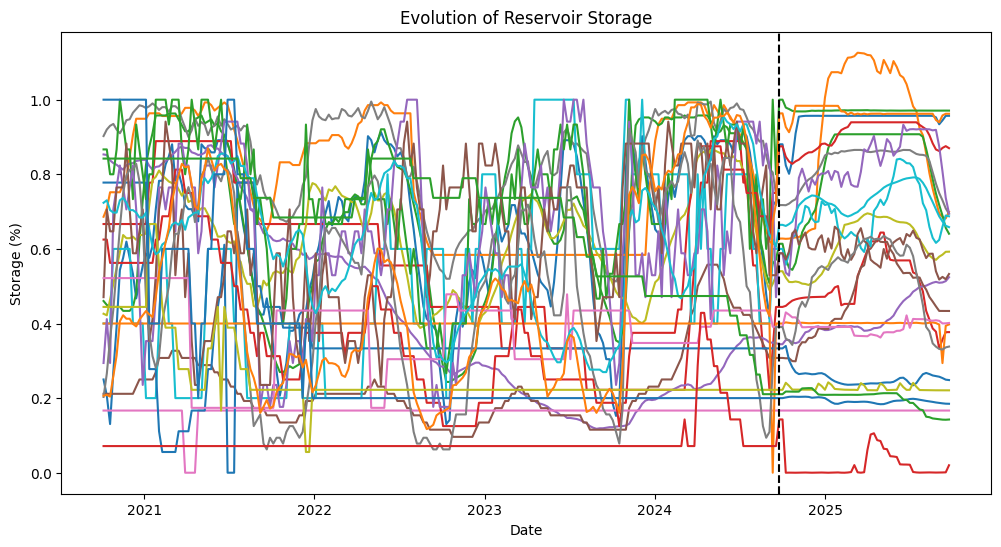

In [23]:
transfers_log = plot_all_reservoirs(reservoirs_list, with_transfers=False, legend=False)

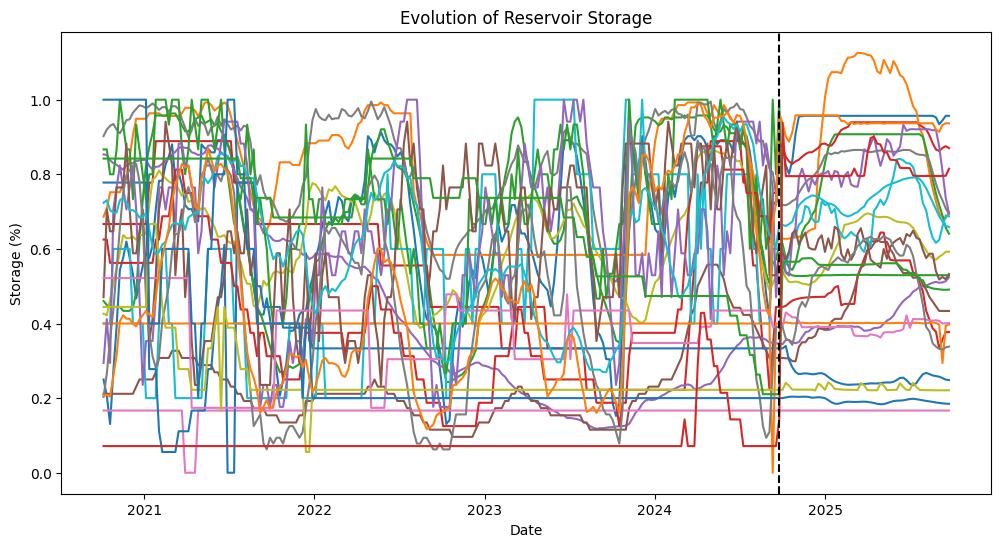

In [47]:
transfers_log = plot_all_reservoirs(reservoirs_list, with_transfers=True, legend=False)

In [31]:
def plot_all_reservoirs_involved(reservoirs_list, with_transfers=False, legend=True):
    id_to_capacity = reservoirs_pd.set_index('id')['capacity'].to_dict()
    difference = {}
    _, transfers_log = make_optimal_transfers(reservoirs_list)

    for _, row in transfers_log.iterrows():
            if row['donor'] not in difference:
                difference[row['donor']] = 0
            difference[row['donor']] -= row['difference']
            if row['receiver'] not in difference:
                difference[row['receiver']] = 0
            difference[row['receiver']] += row['difference']
        
    reservoirs_involved = difference.keys()
    if not with_transfers:
         difference = {}

    next_year_predictions_path = PATHS['processed_data_notebooks'] / 'next_year_predictions.parquet'
    next_year_predictions = pd.read_parquet(next_year_predictions_path)

    water_pd['capacity'] = water_pd['id'].map(id_to_capacity)

    plt.figure(figsize=(12, 6))

    for reservoir in reservoirs_involved:
        reservoir_pd = water_pd[water_pd['id'] == reservoir]
        reservoir_pd.set_index('date', inplace=True)
        df1 = reservoir_pd['storage'][-52*4:]/id_to_capacity[reservoir]
        df2 = (next_year_predictions[reservoir] + difference.get(reservoir, 0))/id_to_capacity[reservoir]
        df = pd.concat([df1, df2], axis=0)
        
        plt.plot(df.index,
                df,
                label=f'Reservoir {int(reservoir)}')
        
    plt.axvline(x=df1.index[-1], color='k', linestyle='--', label='Next Year Prediction')
    plt.xlabel('Date')
    plt.ylabel('Storage (%)')
    plt.title('Evolution of Reservoir Storage')
    if legend:
        plt.legend()
    plt.show()
    return transfers_log

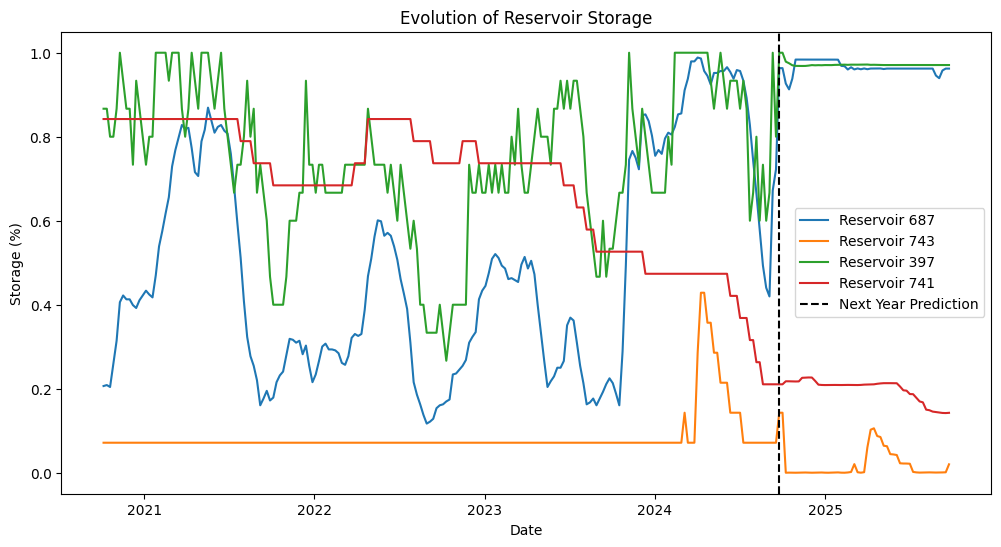

,donor,receiver,difference,cost,critical,worrying,could_give_if_critical,could_give_if_worrying,able_to_donate
0,687,743,11.128889,2.028880e-08,0,0,1,1,1
1,397,741,6.617647,1.898796e-11,0,0,1,1,0


In [32]:
plot_all_reservoirs_involved(reservoirs_list, with_transfers=False, legend=True)

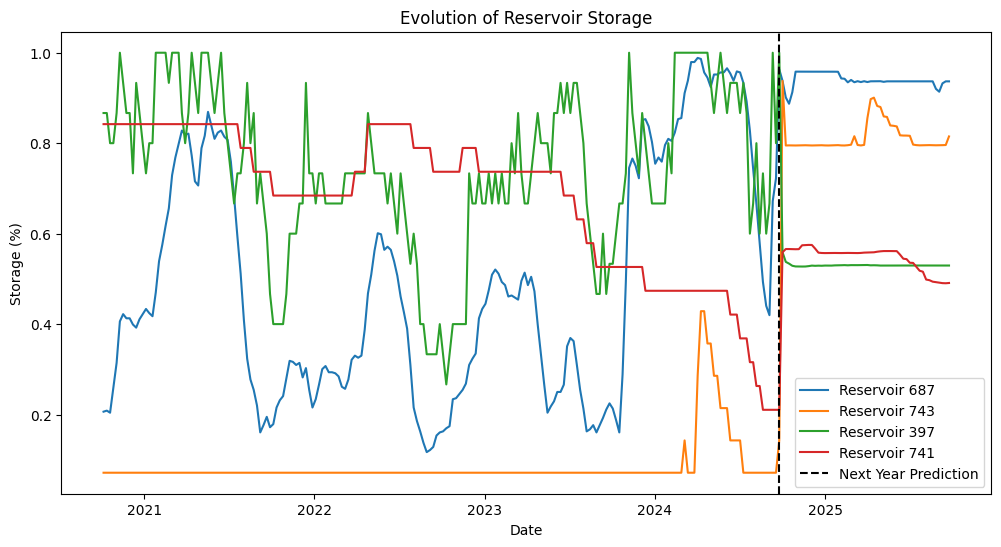

,donor,receiver,difference,cost,critical,worrying,could_give_if_critical,could_give_if_worrying,able_to_donate
0,687,743,11.128889,2.028880e-08,0,0,1,1,1
1,397,741,6.617647,1.898796e-11,0,0,1,1,0


In [33]:
plot_all_reservoirs_involved(reservoirs_list, with_transfers=True, legend=True)